# Laboratorio 5 - Análisis de paquetes y detección de anomalías

**Curso:** CC3067 - Security Data Science  
**Alumno:** Esteban Zambrano
**Fecha:** abril

In [22]:
from scapy.all import rdpcap, Raw, IP, TCP, UDP
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest

## Parte 1 - Análisis de paquetes
Para este ejercicio se utilizará el archivo analisis_paquetes.pcap que se encuentra en CANVAS.

### 1.1 Testeo de la herramienta

In [23]:
packets = rdpcap("../analisis_paquetes.pcap")

print("Tipo:", type(packets))
print("Cantidad de paquetes:", len(packets))
print("\nPrimeros 10 paquetes:\n")

for pkt in packets[:10]:
    print(pkt.summary())

Tipo: <class 'scapy.plist.PacketList'>
Cantidad de paquetes: 62

Primeros 10 paquetes:

Ether / IP / UDP / DNS Qry b'google.com.' / Raw
Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807::200e
Ether / IP / UDP / DNS Qry b'google.com.' / Raw
Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807::200e
Ether / IP / UDP / DNS Qry b'google.com.' / Raw
Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807::200e
Ether / IP / UDP / DNS Qry b'google.com.' / Raw
Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807::200e
Ether / IP / UDP / DNS Qry b'google.com.' / Raw
Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807::200e


Se cargó correctamente el archivo `analisis_paquetes.pcap` utilizando Scapy. 
El tipo de dato obtenido fue `PacketList`, lo cual indica que Scapy almacenó la captura como una lista de paquetes. 
Además, se observó que el archivo contiene 62 paquetes. 
Al imprimir los primeros 10, se identificó tráfico de tipo DNS sobre UDP, con consultas y respuestas relacionadas con `google.com`.

### 1.2 Visualización de columnas básicas

In [24]:
rows = []

for pkt in packets:
    src_ip = None
    dst_ip = None
    src_port = None
    dst_port = None

    if pkt.haslayer(IP):
        src_ip = pkt[IP].src
        dst_ip = pkt[IP].dst

    if pkt.haslayer(UDP):
        src_port = pkt[UDP].sport
        dst_port = pkt[UDP].dport
    elif pkt.haslayer(TCP):
        src_port = pkt[TCP].sport
        dst_port = pkt[TCP].dport

    rows.append({
        "Src Address": src_ip,
        "Dst Address": dst_ip,
        "Src Port": src_port,
        "Dst Port": dst_port
    })

df_basic = pd.DataFrame(rows)

df_basic.head(10)

,Src Address,Dst Address,Src Port,Dst Port
0,10.1.10.53,84.54.22.33,53,53
1,84.54.22.33,10.1.10.53,53,53
2,10.1.10.53,84.54.22.33,53,53
3,84.54.22.33,10.1.10.53,53,53
4,10.1.10.53,84.54.22.33,53,53
5,84.54.22.33,10.1.10.53,53,53
6,10.1.10.53,84.54.22.33,53,53
7,84.54.22.33,10.1.10.53,53,53
8,10.1.10.53,84.54.22.33,53,53
9,84.54.22.33,10.1.10.53,53,53


In [25]:
df_basic

,Src Address,Dst Address,Src Port,Dst Port
0,10.1.10.53,84.54.22.33,53,53
1,84.54.22.33,10.1.10.53,53,53
2,10.1.10.53,84.54.22.33,53,53
3,84.54.22.33,10.1.10.53,53,53
4,10.1.10.53,84.54.22.33,53,53
...,...,...,...,...
57,84.54.22.33,10.1.10.53,53,53
58,10.1.10.53,84.54.22.33,53,53
59,84.54.22.33,10.1.10.53,53,53
60,10.1.10.53,84.54.22.33,53,53


## Estadísticas y detección con Z-Score

### Conversión del pcap a DataFrame

In [26]:
data = []

for pkt in packets:
    src_ip = None
    dst_ip = None
    src_port = None
    dst_port = None

    if pkt.haslayer(IP):
        src_ip = pkt[IP].src
        dst_ip = pkt[IP].dst

    if pkt.haslayer(UDP):
        src_port = pkt[UDP].sport
        dst_port = pkt[UDP].dport
    elif pkt.haslayer(TCP):
        src_port = pkt[TCP].sport
        dst_port = pkt[TCP].dport

    if pkt.haslayer(Raw):
        payload = bytes(pkt[Raw].load)
        payload_len = len(payload)
    else:
        payload = b""
        payload_len = 0

    pkt_len = len(pkt)

    data.append({
        "Src Address": src_ip,
        "Dst Address": dst_ip,
        "Src Port": src_port,
        "Dst Port": dst_port,
        "payload": payload,
        "payload_len": payload_len,
        "pkt_len": pkt_len
    })

df = pd.DataFrame(data)

df.head(10)

,Src Address,Dst Address,Src Port,Dst Port,payload,payload_len,pkt_len
0,10.1.10.53,84.54.22.33,53,53,b'\xef\xbf\xbdPNG\r\n\x1a\n\x00\x00\x00\rIHDR\...,905,975
1,84.54.22.33,10.1.10.53,53,53,b'',0,98
2,10.1.10.53,84.54.22.33,53,53,b':\xef\xbf\xbdle:\xc7\xa9\xef\xbf\xbd\xef\xbf...,919,989
3,84.54.22.33,10.1.10.53,53,53,b'',0,98
4,10.1.10.53,84.54.22.33,53,53,b'\xef\xbf\xbd\xef\xbf\xbd^n\xef\xbf\xbd\'\'\x...,956,1026
5,84.54.22.33,10.1.10.53,53,53,b'',0,98
6,10.1.10.53,84.54.22.33,53,53,b'\xe4\x8e\x91Bj_\xef\xbf\xbda\r\xef\xbf\xbd\x...,942,1012
7,84.54.22.33,10.1.10.53,53,53,b'',0,98
8,10.1.10.53,84.54.22.33,53,53,b'\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xcb\xb4...,947,1017
9,84.54.22.33,10.1.10.53,53,53,b'',0,98


In [27]:
df[["Src Port", "Dst Port"]].value_counts()

Src Port  Dst Port
53        53          58
15812     53           1
23903     53           1
53        15812        1
          23903        1
Name: count, dtype: int64

### 3. Calcule las siguientes estadísticas básicas

In [28]:
## 3a - IP origen más frecuente

src_counts = df['Src Address'].value_counts()
ip_src_most = src_counts.idxmax()

print("IP origen más frecuente:", ip_src_most)
print("\nFrecuencia de IPs origen:")
print(src_counts)

IP origen más frecuente: 10.1.10.53

Frecuencia de IPs origen:
Src Address
10.1.10.53     31
84.54.22.33    29
75.75.75.75     2
Name: count, dtype: int64


In [29]:
## 3b - IP destino más frecuente

dst_counts = df['Dst Address'].value_counts()
ip_dst_most = dst_counts.idxmax()

print("IP destino más frecuente:", ip_dst_most)
print("\nFrecuencia de IPs destino:")
print(dst_counts)

IP destino más frecuente: 10.1.10.53

Frecuencia de IPs destino:
Dst Address
10.1.10.53     31
84.54.22.33    29
75.75.75.75     2
Name: count, dtype: int64


In [30]:
## 3c - IPs con las que se comunica la IP origen más frecuente

dst_of_src_most = df[df['Src Address'] == ip_src_most]['Dst Address'].value_counts()

print(f"IPs destino con las que se comunica {ip_src_most}:")
print(dst_of_src_most)

IPs destino con las que se comunica 10.1.10.53:
Dst Address
84.54.22.33    29
75.75.75.75     2
Name: count, dtype: int64


In [31]:
## 3d - Puertos destino a los que se comunica la IP origen más frecuente

dports_of_src_most = df[df['Src Address'] == ip_src_most]['Dst Port'].value_counts()

print(f"Puertos destino a los que se comunica {ip_src_most}:")
print(dports_of_src_most)

Puertos destino a los que se comunica 10.1.10.53:
Dst Port
53    31
Name: count, dtype: int64


In [32]:
## 3e - Puertos origen con los que se comunica la IP destino más frecuente

sports_of_dst_most = df[df['Dst Address'] == ip_dst_most]['Src Port'].value_counts()

print(f"Puertos origen con los que se comunica {ip_dst_most}:")
print(sports_of_dst_most)

Puertos origen con los que se comunica 10.1.10.53:
Src Port
53    31
Name: count, dtype: int64


In [33]:
## 3f - Propósito de los puertos más frecuentes

most_dport = dports_of_src_most.idxmax()
most_sport = sports_of_dst_most.idxmax()

print("Puerto destino más frecuente (inciso d):", most_dport)
print("Puerto origen más frecuente (inciso e):", most_sport)

Puerto destino más frecuente (inciso d): 53
Puerto origen más frecuente (inciso e): 53


**3a)**  
La IP origen más frecuente es `10.1.10.53`, con un total de 31 paquetes. Esto indica que dicha dirección es la principal emisora de tráfico dentro de la captura analizada.

---

**3b)**  
La IP destino más frecuente también es `10.1.10.53`, con un total de 31 paquetes. Esto sugiere que esta dirección no solo genera tráfico, sino que también participa activamente como receptor dentro de la conversación predominante observada en la captura.

---

**3c)**  
La IP `10.1.10.53`, identificada como la IP origen más frecuente, se comunica principalmente con la dirección `84.54.22.33`, con un total de 29 paquetes, y en menor medida con `75.75.75.75`. Esto muestra que el tráfico está fuertemente concentrado en una conversación específica entre dos hosts.

---

**3d)**  
La IP `10.1.10.53` se comunica hacia el puerto destino `53` en todos los casos observados. Esto indica que el tráfico saliente de esta dirección está asociado principalmente al protocolo DNS.

---

**3e)**  
La IP destino más frecuente (`10.1.10.53`) recibe tráfico principalmente desde el puerto origen `53`. Esto refuerza la observación de que la mayor parte de la comunicación en la captura está relacionada con tráfico que utiliza el puerto DNS.

---

**3f)**  
El puerto `53` corresponde al protocolo DNS (Domain Name System), el cual se utiliza normalmente para la resolución de nombres de dominio. Sin embargo, se observa un comportamiento inusual: la comunicación ocurre predominantemente utilizando el puerto `53` tanto en origen como en destino (`53 → 53`). En un escenario comun de DNS, el cliente utiliza un puerto efímero para comunicarse con el servidor en el puerto `53`, y posteriormente recibe la respuesta desde el puerto `53` hacia ese puerto efímero.

Este patrón, junto con la concentración del tráfico entre `10.1.10.53` y `84.54.22.33`, sugiere un posible uso anómalo del protocolo DNS. Esta sospecha será evaluada con mayor detalle en las siguientes secciones mediante técnicas estadísticas, gráficas, aprendizaje automático e inspección manual del payload.

### 4. Z-Score sobre el tamaño de payload

In [34]:
## 4a - Cálculo de Z-score sobre payload_len

df['zscore_payload'] = zscore(df['payload_len'])

anom_z2 = df[df['zscore_payload'].abs() > 2]
anom_z3 = df[df['zscore_payload'].abs() > 3]

print("Paquetes con |Z| > 2:")
print(anom_z2[['Src Address', 'Dst Address', 'Src Port', 'Dst Port', 'payload_len', 'zscore_payload']])

print("\nCantidad de paquetes con |Z| > 2:", len(anom_z2))

print("\nPaquetes con |Z| > 3:")
print(anom_z3[['Src Address', 'Dst Address', 'Src Port', 'Dst Port', 'payload_len', 'zscore_payload']])

print("\nCantidad de paquetes con |Z| > 3:", len(anom_z3))

Paquetes con |Z| > 2:
Empty DataFrame
Columns: [Src Address, Dst Address, Src Port, Dst Port, payload_len, zscore_payload]
Index: []

Cantidad de paquetes con |Z| > 2: 0

Paquetes con |Z| > 3:
Empty DataFrame
Columns: [Src Address, Dst Address, Src Port, Dst Port, payload_len, zscore_payload]
Index: []

Cantidad de paquetes con |Z| > 3: 0


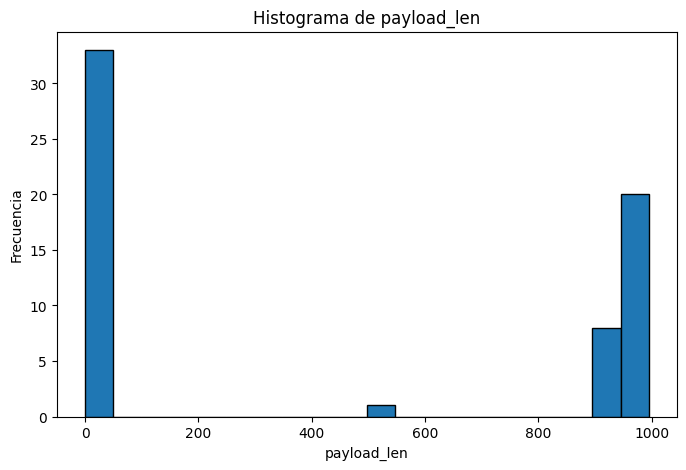

In [35]:
## 4b - Histograma de payload_len

plt.figure(figsize=(8,5))
plt.hist(df['payload_len'], bins=20, edgecolor='black')
plt.xlabel('payload_len')
plt.ylabel('Frecuencia')
plt.title('Histograma de payload_len')
plt.show()

In [36]:
## 4c - Z-score usando conocimiento de dominio DNS

dns_mean = 50
dns_std = 15

df['zscore_dns'] = (df['payload_len'] - dns_mean) / dns_std

anom_domain_z2 = df[df['zscore_dns'].abs() > 2]
anom_domain_z3 = df[df['zscore_dns'].abs() > 3]

print("Paquetes con |Z_domain| > 2:")
print(anom_domain_z2[['Src Address', 'Dst Address', 'Src Port', 'Dst Port', 'payload_len', 'zscore_dns']])

print("\nCantidad de paquetes con |Z_domain| > 2:", len(anom_domain_z2))

print("\nPaquetes con |Z_domain| > 3:")
print(anom_domain_z3[['Src Address', 'Dst Address', 'Src Port', 'Dst Port', 'payload_len', 'zscore_dns']])

print("\nCantidad de paquetes con |Z_domain| > 3:", len(anom_domain_z3))

Paquetes con |Z_domain| > 2:
    Src Address  Dst Address  Src Port  Dst Port  payload_len  zscore_dns
0    10.1.10.53  84.54.22.33        53        53          905   57.000000
1   84.54.22.33   10.1.10.53        53        53            0   -3.333333
2    10.1.10.53  84.54.22.33        53        53          919   57.933333
3   84.54.22.33   10.1.10.53        53        53            0   -3.333333
4    10.1.10.53  84.54.22.33        53        53          956   60.400000
..          ...          ...       ...       ...          ...         ...
57  84.54.22.33   10.1.10.53        53        53            0   -3.333333
58   10.1.10.53  84.54.22.33        53        53          913   57.533333
59  84.54.22.33   10.1.10.53        53        53            0   -3.333333
60   10.1.10.53  84.54.22.33        53        53          532   32.133333
61  84.54.22.33   10.1.10.53        53        53            0   -3.333333

[62 rows x 6 columns]

Cantidad de paquetes con |Z_domain| > 2: 62

Paquetes con |

**4a)**  
El Z-score calculado utilizando la media y desviación estándar del propio conjunto de datos no detectó paquetes con |Z| > 2 ni con |Z| > 3. Esto indica que, desde una perspectiva puramente estadística basada en el dataset, no se identifican valores extremos. Sin embargo, esto puede ser engañoso, ya que la media y la desviación estándar están influenciadas por los mismos datos, los cuales ya contienen valores atípicos en gran proporción.

---

**4b)**  
El histograma de `payload_len` muestra que la distribución de los datos no es normal (gaussiana), sino que presenta una forma bimodal, con una concentración de valores en 0 bytes y otra alrededor de 900–1000 bytes. Esta forma de distribución afecta directamente la efectividad del Z-score, ya que este método asume una distribución aproximadamente normal. Al no cumplirse esta condición, los valores anómalos no son detectados correctamente.

---

**4c)**  
Al aplicar el Z-score utilizando conocimiento de dominio del protocolo DNS (media ≈ 50 bytes y desviación estándar ≈ 15 bytes), se detectó que todos los paquetes presentan |Z| > 2 e incluso |Z| > 3. Esto indica que los tamaños de los payloads observados se desvían significativamente del comportamiento esperado de consultas DNS legítimas. En total, se detectaron 62 paquetes como anómalos bajo este criterio.

---

**4d)**  
Este análisis demuestra la importancia de conocer el protocolo que se está analizando al aplicar técnicas de detección de anomalías. El uso exclusivo de estadísticas calculadas sobre el mismo conjunto de datos puede ocultar comportamientos anómalos si el dataset ya está contaminado. En cambio, el uso de conocimiento de dominio permite establecer referencias más realistas y detectar anomalías con mayor precisión. Esto evidencia que las técnicas automáticas deben complementarse con contexto del protocolo para obtener resultados confiables.

## Gráficas

### 5. Gráficas de payload

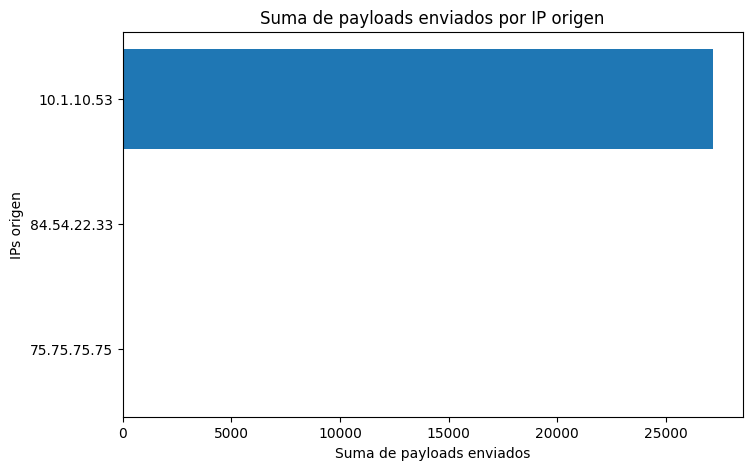

In [37]:
## 5a - Gráfica 2D: IPs origen vs suma de payloads enviados

payload_by_src = df.groupby('Src Address')['payload_len'].sum().sort_values()

plt.figure(figsize=(8,5))
plt.barh(payload_by_src.index.astype(str), payload_by_src.values)
plt.xlabel('Suma de payloads enviados')
plt.ylabel('IPs origen')
plt.title('Suma de payloads enviados por IP origen')
plt.show()

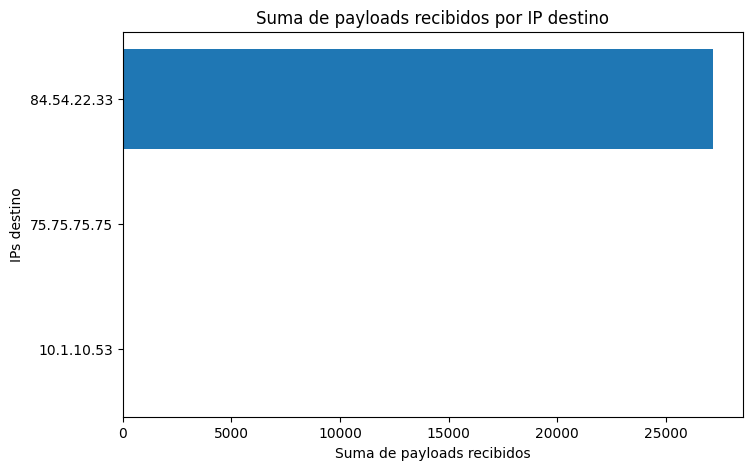

In [38]:
## 5b - Gráfica 2D: IPs destino vs suma de payloads recibidos

payload_by_dst = df.groupby('Dst Address')['payload_len'].sum().sort_values()

plt.figure(figsize=(8,5))
plt.barh(payload_by_dst.index.astype(str), payload_by_dst.values)
plt.xlabel('Suma de payloads recibidos')
plt.ylabel('IPs destino')
plt.title('Suma de payloads recibidos por IP destino')
plt.show()

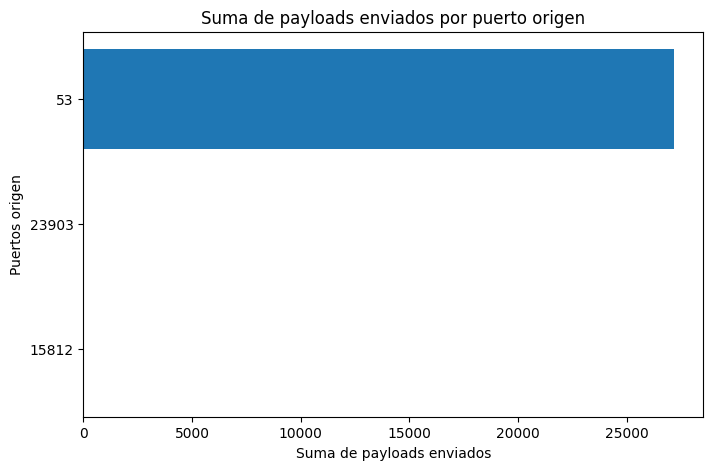

In [39]:
## 5c - Gráfica 2D: puertos origen vs suma de payloads enviados

payload_by_sport = df.groupby('Src Port')['payload_len'].sum().sort_values()

plt.figure(figsize=(8,5))
plt.barh(payload_by_sport.index.astype(str), payload_by_sport.values)
plt.xlabel('Suma de payloads enviados')
plt.ylabel('Puertos origen')
plt.title('Suma de payloads enviados por puerto origen')
plt.show()

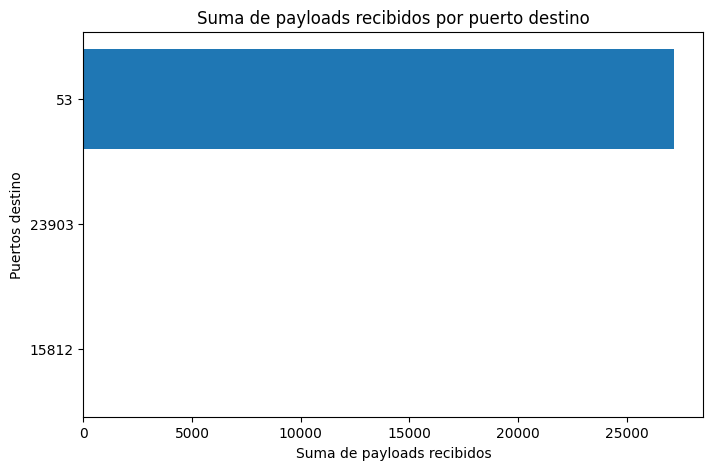

In [40]:
## 5d - Gráfica 2D: puertos destino vs suma de payloads recibidos

payload_by_dport = df.groupby('Dst Port')['payload_len'].sum().sort_values()

plt.figure(figsize=(8,5))
plt.barh(payload_by_dport.index.astype(str), payload_by_dport.values)
plt.xlabel('Suma de payloads recibidos')
plt.ylabel('Puertos destino')
plt.title('Suma de payloads recibidos por puerto destino')
plt.show()

In [42]:
print(payload_by_src)
print()
print(payload_by_dst)
print()
print(payload_by_sport)
print()
print(payload_by_dport)

Src Address
75.75.75.75        0
84.54.22.33        0
10.1.10.53     27167
Name: payload_len, dtype: int64

Dst Address
10.1.10.53         0
75.75.75.75        0
84.54.22.33    27167
Name: payload_len, dtype: int64

Src Port
15812        0
23903        0
53       27167
Name: payload_len, dtype: int64

Dst Port
15812        0
23903        0
53       27167
Name: payload_len, dtype: int64


## Respuestas - Inciso 5 (Gráficas de payload)

**5a)**  
La gráfica de IPs origen muestra que la dirección `10.1.10.53` concentra prácticamente toda la suma de payloads enviados. Esto indica que esta IP es la principal generadora de datos dentro de la captura, lo cual coincide con el análisis estadístico previo.

---

**5b)**  
La gráfica de IPs destino muestra que la dirección `84.54.22.33` recibe prácticamente toda la suma de payloads observados. Esto refuerza la existencia de una comunicación dominante entre `10.1.10.53` y `84.54.22.33`.

---

**5c)**  
La gráfica de puertos origen muestra que el puerto `53` concentra casi todo el payload enviado. Esto indica que el tráfico con mayor volumen de datos está siendo transmitido a través de DNS, lo cual resulta sospechoso debido a los tamaños de payload observados.

---

**5d)**  
La gráfica de puertos destino muestra que el puerto `53` concentra la suma total relevante de payloads recibidos, mientras que los puertos `15812` y `23903` aparecen con valor 0. Esto significa que, aunque hubo paquetes asociados a esos puertos, no transportaron payload significativo según la extracción realizada. En conjunto, las gráficas confirman que el tráfico con contenido relevante está fuertemente concentrado en el puerto 53, lo que apoya la hipótesis de un uso anómalo del protocolo DNS.

## Detección automática con Isolation Forest

### 6. Isolation Forest

In [43]:
## 6a - Detección de anomalías con Isolation Forest

from sklearn.ensemble import IsolationForest

# Ajuste del contamination (máximo permitido)
contamination = 0.5

model = IsolationForest(contamination=contamination, random_state=42)

features = df[['payload_len', 'pkt_len']]

df['anomaly_iforest'] = model.fit_predict(features)

# -1 = anomalía, 1 = normal
anomalies_if = df[df['anomaly_iforest'] == -1]

print("Paquetes detectados como anomalías:")
print(anomalies_if[['Src Address', 'Dst Address', 'Src Port', 'Dst Port', 'payload_len', 'pkt_len']])

print("\nCantidad de anomalías detectadas:", len(anomalies_if))

Paquetes detectados como anomalías:
    Src Address  Dst Address  Src Port  Dst Port  payload_len  pkt_len
0    10.1.10.53  84.54.22.33        53        53          905      975
2    10.1.10.53  84.54.22.33        53        53          919      989
4    10.1.10.53  84.54.22.33        53        53          956     1026
6    10.1.10.53  84.54.22.33        53        53          942     1012
8    10.1.10.53  84.54.22.33        53        53          947     1017
10   10.1.10.53  84.54.22.33        53        53          989     1059
12   10.1.10.53  84.54.22.33        53        53          952     1022
14   10.1.10.53  84.54.22.33        53        53          923      993
16   10.1.10.53  84.54.22.33        53        53          903      973
18   10.1.10.53  84.54.22.33        53        53          936     1006
20   10.1.10.53  84.54.22.33        53        53          995     1065
22   10.1.10.53  75.75.75.75     15812        53            0       79
23   10.1.10.53  75.75.75.75     23903   

**6a)**  
Se entrenó un modelo de Isolation Forest utilizando las variables `payload_len` y `pkt_len`.

De acuerdo con el enunciado, el valor de `contamination` debía calcularse como la proporción entre el número de paquetes detectados en el inciso 4c y el número total de paquetes. En este caso, dicha proporción fue `62/62 = 1.0`. Sin embargo, el modelo `IsolationForest` solo acepta valores de `contamination` en el rango `(0, 0.5]`, por lo que se utilizó `0.5` como el valor máximo permitido para poder ejecutar el modelo.

Con este ajuste, el modelo identificó 29 paquetes como anomalías. Estos corresponden principalmente a paquetes con tamaños de payload elevados (aproximadamente entre 900 y 1000 bytes), asociados a la comunicación entre las direcciones IP `10.1.10.53` y `84.54.22.33`.

Adicionalmente, algunos paquetes con `payload_len = 0` y puertos menos frecuentes también fueron identificados como anomalías, debido a que presentan características diferentes al patrón dominante del tráfico.

---

**6b)**  
Las anomalías detectadas por el modelo coinciden en gran medida con los patrones sospechosos identificados previamente mediante el análisis con Z-score y las gráficas.

En particular, los paquetes con mayor tamaño de payload y asociados al flujo principal entre `10.1.10.53` y `84.54.22.33` son consistentemente identificados como anómalos.

Sin embargo, a diferencia del Z-score basado en conocimiento de dominio, que clasificó todos los paquetes como anómalos, el modelo de Isolation Forest solo identifica un subconjunto de ellos. Esto se debe a que el modelo evalúa la rareza relativa dentro del conjunto de datos, y no en comparación con un comportamiento esperado del protocolo.

En conjunto, ambos enfoques confirman que el tráfico presenta características anómalas, reforzando la hipótesis de un uso indebido del protocolo DNS para transportar datos.

## Investigación del payload (confirmación manual)

### 7. Investigación del payload

In [44]:
## 7a - Filtrar conexiones con la IP origen más frecuente

df_src_most = df[df['Src Address'] == ip_src_most]

print(df_src_most.head())
print("\nCantidad de paquetes:", len(df_src_most))

  Src Address  Dst Address  Src Port  Dst Port  \
0  10.1.10.53  84.54.22.33        53        53   
2  10.1.10.53  84.54.22.33        53        53   
4  10.1.10.53  84.54.22.33        53        53   
6  10.1.10.53  84.54.22.33        53        53   
8  10.1.10.53  84.54.22.33        53        53   

                                             payload  payload_len  pkt_len  \
0  b'\xef\xbf\xbdPNG\r\n\x1a\n\x00\x00\x00\rIHDR\...          905      975   
2  b':\xef\xbf\xbdle:\xc7\xa9\xef\xbf\xbd\xef\xbf...          919      989   
4  b'\xef\xbf\xbd\xef\xbf\xbd^n\xef\xbf\xbd\'\'\x...          956     1026   
6  b'\xe4\x8e\x91Bj_\xef\xbf\xbda\r\xef\xbf\xbd\x...          942     1012   
8  b'\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xcb\xb4...          947     1017   

   zscore_payload  zscore_dns  anomaly_iforest  
0        0.991938   57.000000               -1  
2        1.021686   57.933333               -1  
4        1.100307   60.400000               -1  
6        1.070558   59.466667     

In [45]:
## 7b - Agrupar por Src Address, Dst Address y payload

grouped_payload = df_src_most.groupby(['Src Address', 'Dst Address'])['payload_len'].sum()

print(grouped_payload)

Src Address  Dst Address
10.1.10.53   75.75.75.75        0
             84.54.22.33    27167
Name: payload_len, dtype: int64


In [46]:
## 7c - Obtener la IP que más intercambia bytes con la IP origen más frecuente

dst_most_bytes = grouped_payload.idxmax()[1]

print("IP que más intercambia bytes:", dst_most_bytes)

IP que más intercambia bytes: 84.54.22.33


In [47]:
## 7d - Filtrar conversación entre IP origen más frecuente y la IP sospechosa

df_conversation = df[
    (df['Src Address'] == ip_src_most) &
    (df['Dst Address'] == dst_most_bytes)
]

print(df_conversation.head())
print("\nCantidad de paquetes en la conversación:", len(df_conversation))

  Src Address  Dst Address  Src Port  Dst Port  \
0  10.1.10.53  84.54.22.33        53        53   
2  10.1.10.53  84.54.22.33        53        53   
4  10.1.10.53  84.54.22.33        53        53   
6  10.1.10.53  84.54.22.33        53        53   
8  10.1.10.53  84.54.22.33        53        53   

                                             payload  payload_len  pkt_len  \
0  b'\xef\xbf\xbdPNG\r\n\x1a\n\x00\x00\x00\rIHDR\...          905      975   
2  b':\xef\xbf\xbdle:\xc7\xa9\xef\xbf\xbd\xef\xbf...          919      989   
4  b'\xef\xbf\xbd\xef\xbf\xbd^n\xef\xbf\xbd\'\'\x...          956     1026   
6  b'\xe4\x8e\x91Bj_\xef\xbf\xbda\r\xef\xbf\xbd\x...          942     1012   
8  b'\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xcb\xb4...          947     1017   

   zscore_payload  zscore_dns  anomaly_iforest  
0        0.991938   57.000000               -1  
2        1.021686   57.933333               -1  
4        1.100307   60.400000               -1  
6        1.070558   59.466667     

In [48]:
## 7e - Extraer payloads en un array

payloads_array = df_conversation['payload'].tolist()

print("Cantidad de payloads:", len(payloads_array))

Cantidad de payloads: 29


In [49]:
## 7f - Mostrar contenido del primer payload

first_payload = payloads_array[0]

print(first_payload)

b'\xef\xbf\xbdPNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01b\x00\x00\x00\xef\xbf\xbd\x08\x06\x00\x00\x00(\xef\xbf\xbdTR\x00\x00:\xef\xbf\xbdIDATx\xef\xbf\xbd\xef\xbf\xbd\t|T\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd;K\x12\x08;\x08\xef\xbf\xbd\nE\xef\xbf\xbd\xef\xbf\xbd$\x19\xef\xbf\xbd\xef\xbf\xbdZi\xdf\xaa-\xef\xbf\xbd;N2\xef\xbf\xbd\xef\xbf\xbdV\xef\xbf\xbdV\xef\xbf\xbda\xef\xbf\xbdZ\x11!\xef\xbf\xbd\xef\xbf\xbd\x01\xdc\xbbik[\xef\xbf\xbd.ok\xef\xbf\xbde\xef\xbf\xbd\x01\\\xef\xbf\xbd\xef\xbf\xbd]\xef\xbf\xbd-\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbdd\xef\xbf\xbd\x08\xef\xbf\xbd\x08\xef\xbf\xbd\xef\xbf\xbdg\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd<\xef\xbf\xbd\xef\xbf\xbdL\x12\xef\xbf\xbd$3wf\xef\xbf\xbd\xef\xbf\xbd\x02<_\r\xef\xbf\xbdY\xef\xbf\xbdr\xef\xbf\xbd\xef\xbf\xbdy\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\x1c\r\x18\xef\xbf\xbd8c\xef\xbf\xbdew\r\x1e\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\x13\xef\xbf\xbdiaK\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbdu}\xc5\xb2w\xe

In [50]:
## 7g - Mostrar primeros bytes del payload

print(first_payload[:50])

b'\xef\xbf\xbdPNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01b\x00\x00\x00\xef\xbf\xbd\x08\x06\x00\x00\x00(\xef\xbf\xbdTR\x00\x00:\xef\xbf\xbdIDATx'


**7a)**  
Se filtraron las conexiones correspondientes a la IP origen más frecuente (`10.1.10.53`), lo que permitió aislar el flujo principal de tráfico identificado en las etapas previas del análisis.

---

**7b)**  
Al agrupar los datos por dirección origen y destino, se observó que la mayor cantidad de bytes intercambiados corresponde a la comunicación entre `10.1.10.53` y `84.54.22.33`, con un total de 27167 bytes, lo cual confirma una conversación dominante.

---

**7c)**  
La IP que más ha intercambiado bytes con la IP origen más frecuente es `84.54.22.33`, coincidiendo con la IP sospechosa identificada previamente mediante el análisis estadístico, gráfico y de aprendizaje automático.

---

**7d)**  
Se aisló la conversación entre `10.1.10.53` y `84.54.22.33`, obteniendo un subconjunto de 29 paquetes que representan el flujo principal de datos.

---

**7e)**  
Se extrajeron los payloads de estos paquetes y se almacenaron en un arreglo para facilitar su análisis.

---

**7f)**  
Se visualizó el contenido del primer payload, observándose datos binarios no estructurados que no corresponden a consultas DNS normales.

---

**7g)**  
Al examinar los primeros bytes del payload, se identificó la firma característica de un archivo PNG (`PNG\r\n\x1a\n`). Esto indica que el contenido del tráfico incluye datos binarios correspondientes a una imagen.

Este comportamiento no es consistente con el uso normal del protocolo DNS, el cual se utiliza únicamente para resolución de nombres y no para transferencia de archivos.

Por lo tanto, se concluye que el ataque detectado corresponde a un caso de DNS tunneling o exfiltración de datos, en el cual el protocolo DNS es utilizado como canal encubierto para transmitir información.

Este análisis demuestra la importancia de combinar técnicas automáticas (Z-score, Isolation Forest) con la inspección manual del payload, ya que las primeras permiten identificar tráfico sospechoso, mientras que la segunda permite confirmar la naturaleza del ataque.